In [1]:
import os
from pathlib import Path
import jwst
print(jwst.__version__)
from jwst import datamodels
from jwst.datamodels import dqflags
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
#plt.rcParams['mathtext.default'] = 'regular'
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit, minimize
from scipy.stats import norm, poisson
from scipy.special import gamma
from scipy.interpolate import interp1d
from pathlib import Path
# import natural units:
import natural_units as nu
# multi-core/thread:
import concurrent.futures
import math
import matplotlib.ticker as ticker

# convert charge to sigma:
def sigma_from_charge(charge, mdm):
    return 16 * np.pi * nu.aEM**2 * charge**2 * nu.Reduced_Mass(mdm, nu.mElectron)**2 / (nu.aEM * nu.mElectron)**4 / nu.cm**2

def charge_sigma_conversion(arr):
    dim = len(arr)
    limit = np.zeros((dim,2))
    limit[:,0] = arr[:,0]
    for i_terr in range(dim):
        limit[i_terr,1] = sigma_from_charge(arr[i_terr,1], arr[i_terr,0])
    return limit

1.19.2


where do all the bounds come from?? \
SLAC: https://arxiv.org/abs/hep-ex/9804008 \
LSND and MiniBooNE: https://arxiv.org/abs/1806.03310 \
ArgoNeuT: https://arxiv.org/abs/1911.07996 \
SENSEI: https://arxiv.org/abs/2305.04964 \
BEBC: https://arxiv.org/abs/2011.08153 \
milliQan: https://arxiv.org/abs/2005.06518 \
LEP: https://iopscience.iop.org/article/10.1088/1126-6708/2000/05/003 \
LHC: https://arxiv.org/abs/1410.6816  \
XENON1T cosmic: https://arxiv.org/abs/2010.11190 \
Super-K cosmic: https://arxiv.org/abs/2002.11732 \
\
all others: \
molecular cloud: https://arxiv.org/abs/2211.05787 \



In [2]:
dn_min = -200
dn_max = 400
dn_range = range(dn_min, dn_max)
log_m_min  = -3
log_m_max  = 1
n_m    = 17   # From 1e-3  to 10 GeV
m_grid      = np.logspace(log_m_min, log_m_max, n_m)
#log cs shift from the balloon line
center_line = np.array([2.15504637e-23, 1.53030461e-23, 1.26359147e-23, 1.61669130e-23,
       2.40008514e-23, 4.03532201e-23, 6.95747264e-23, 1.40957345e-22,
       2.84518575e-22, 5.17381239e-22, 1.08351297e-21, 2.15203017e-21,
       4.12016417e-21, 7.78952222e-21, 1.45615810e-20, 2.70914228e-20,
       4.94000000e-20])
log_cs_min = -3
log_cs_max = 0
n_cs   = 25
cs_grid = np.logspace(log_cs_min, log_cs_max, n_cs)

# signal_gird = np.loadtxt('../SHIELDING_RESULT/signal_grid.txt')

jwst_result_path = Path('../mask/results/masked')
# 使用 iterdir() 遍历目录中的文件，并只选择 .txt 文件
jwst_pvd = [file for file in jwst_result_path.iterdir() if file.suffix == ".txt" and file.stem != "output" and '00001_nrs2' in file.stem]

other_curves_path = Path('./other_curves')
CMB_Neff = np.loadtxt(other_curves_path / 'CMB_Neff.txt')
BBN_Neff = np.loadtxt(other_curves_path / 'BBN_Neff.txt')
XQC = np.loadtxt(other_curves_path / 'XQC_4e-3.txt')
CMB = np.loadtxt(other_curves_path / 'CMB.txt')
CMB_Neff_2 = np.loadtxt(other_curves_path / 'CMB_Neff_2.txt')
BBN_Neff_2 = np.loadtxt(other_curves_path / 'BBN_Neff_2.txt')
Earth_magnetic_field = np.loadtxt(other_curves_path / 'Earth_magnetic_field.txt')
DD_upper = np.loadtxt(other_curves_path / 'DD_upper.txt')
DD_lower_100_percent = np.loadtxt(other_curves_path / 'DD_lower_100_percent.txt')
DD_x_points = np.sort(np.concatenate((DD_upper[:,0], DD_lower_100_percent[:,0])))
DD_upper_interp = interp1d(DD_upper[:,0], DD_upper[:,1], bounds_error=False, fill_value="extrapolate")
DD_lower_100_interp = interp1d(DD_lower_100_percent[:,0], DD_lower_100_percent[:,1], bounds_error=False, fill_value="extrapolate")
RRS_upper = np.loadtxt(other_curves_path / 'RRS_upper.txt')
RRS_lower = np.loadtxt(other_curves_path / 'RRS_lower.txt')
RRS_x_points = RRS_lower[1:,0]
RRS_upper_interp = interp1d(RRS_upper[:,0], RRS_upper[:,1], bounds_error=False, fill_value="extrapolate")
RRS_lower_interp = interp1d(RRS_lower[:,0], RRS_lower[:,1], bounds_error=False, fill_value="extrapolate")
molecular_cloud_dense_upper = np.loadtxt(other_curves_path / 'molecular_cloud_dense_upper.txt')
molecular_cloud_diffuse = np.loadtxt(other_curves_path / 'molecular_cloud_diffuse.txt')
# accelerator based limits:
SLAC = np.loadtxt(other_curves_path / 'SLAC.txt')
terrestrial_limits = np.loadtxt(other_curves_path / 'terrestrial_limits.txt')
LSND_charge = np.loadtxt(other_curves_path / 'LSND_charge.txt')
LSND = charge_sigma_conversion(LSND_charge)
miniboone_charge = np.loadtxt(other_curves_path / 'miniboone_charge.txt')
miniboone = charge_sigma_conversion(miniboone_charge)
SENSEI_charge = np.loadtxt(other_curves_path / 'SENSEI_charge.txt')
SENSEI = charge_sigma_conversion(SENSEI_charge)
BEBC_charge = np.loadtxt(other_curves_path / 'BEBC_charge.txt')
BEBC = charge_sigma_conversion(BEBC_charge)
milliQan_charge = np.loadtxt(other_curves_path / 'milliQan_charge.txt')
milliQan = charge_sigma_conversion(milliQan_charge)
LEP_charge = np.loadtxt(other_curves_path / 'LEP_charge.txt')
LEP = charge_sigma_conversion(LEP_charge)
ArgoNeuT_charge = np.loadtxt(other_curves_path / 'ArgoNeuT_charge.txt')
ArgoNeuT = charge_sigma_conversion(ArgoNeuT_charge)
# cosmic produced:
Super_K = np.loadtxt(other_curves_path / 'Super-K.txt')
XENON1T_4e_3_charge = np.loadtxt(other_curves_path / 'XENON1T_charge_4e-3.txt')
XENON1T_4e_3 = charge_sigma_conversion(XENON1T_4e_3_charge)
# others:
darkness_upper = np.loadtxt(other_curves_path / 'DarkNESS.txt')
darkness_mod = np.loadtxt(other_curves_path / 'darkness_mod.txt')
darkness_rate = np.loadtxt(other_curves_path / 'darkness_rate.txt')

frac_1_dir_constraints_dir = './advan_constraint/frac_1/constraints/'
best_frac_1_grid = np.zeros((25,17))   # cs from 1e-6 to 1e-3 of center line
for file in Path(frac_1_dir_constraints_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_frac_1_grid += constraint_grid
best_frac_1_grid = (best_frac_1_grid>0)
find_non_zero = np.sum(best_frac_1_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_1_frac_limit = np.zeros((17 - constraint_start, 2))
for col in range(constraint_start, 17):
    indices = np.where(best_frac_1_grid[:, col] == 1)[0]
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_1_frac_limit[index_temp, 0] = m_grid[col]
    best_1_frac_limit[index_temp, 1] = center_line[col] * 1e-3 * cs_grid[lower_index]

findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' 

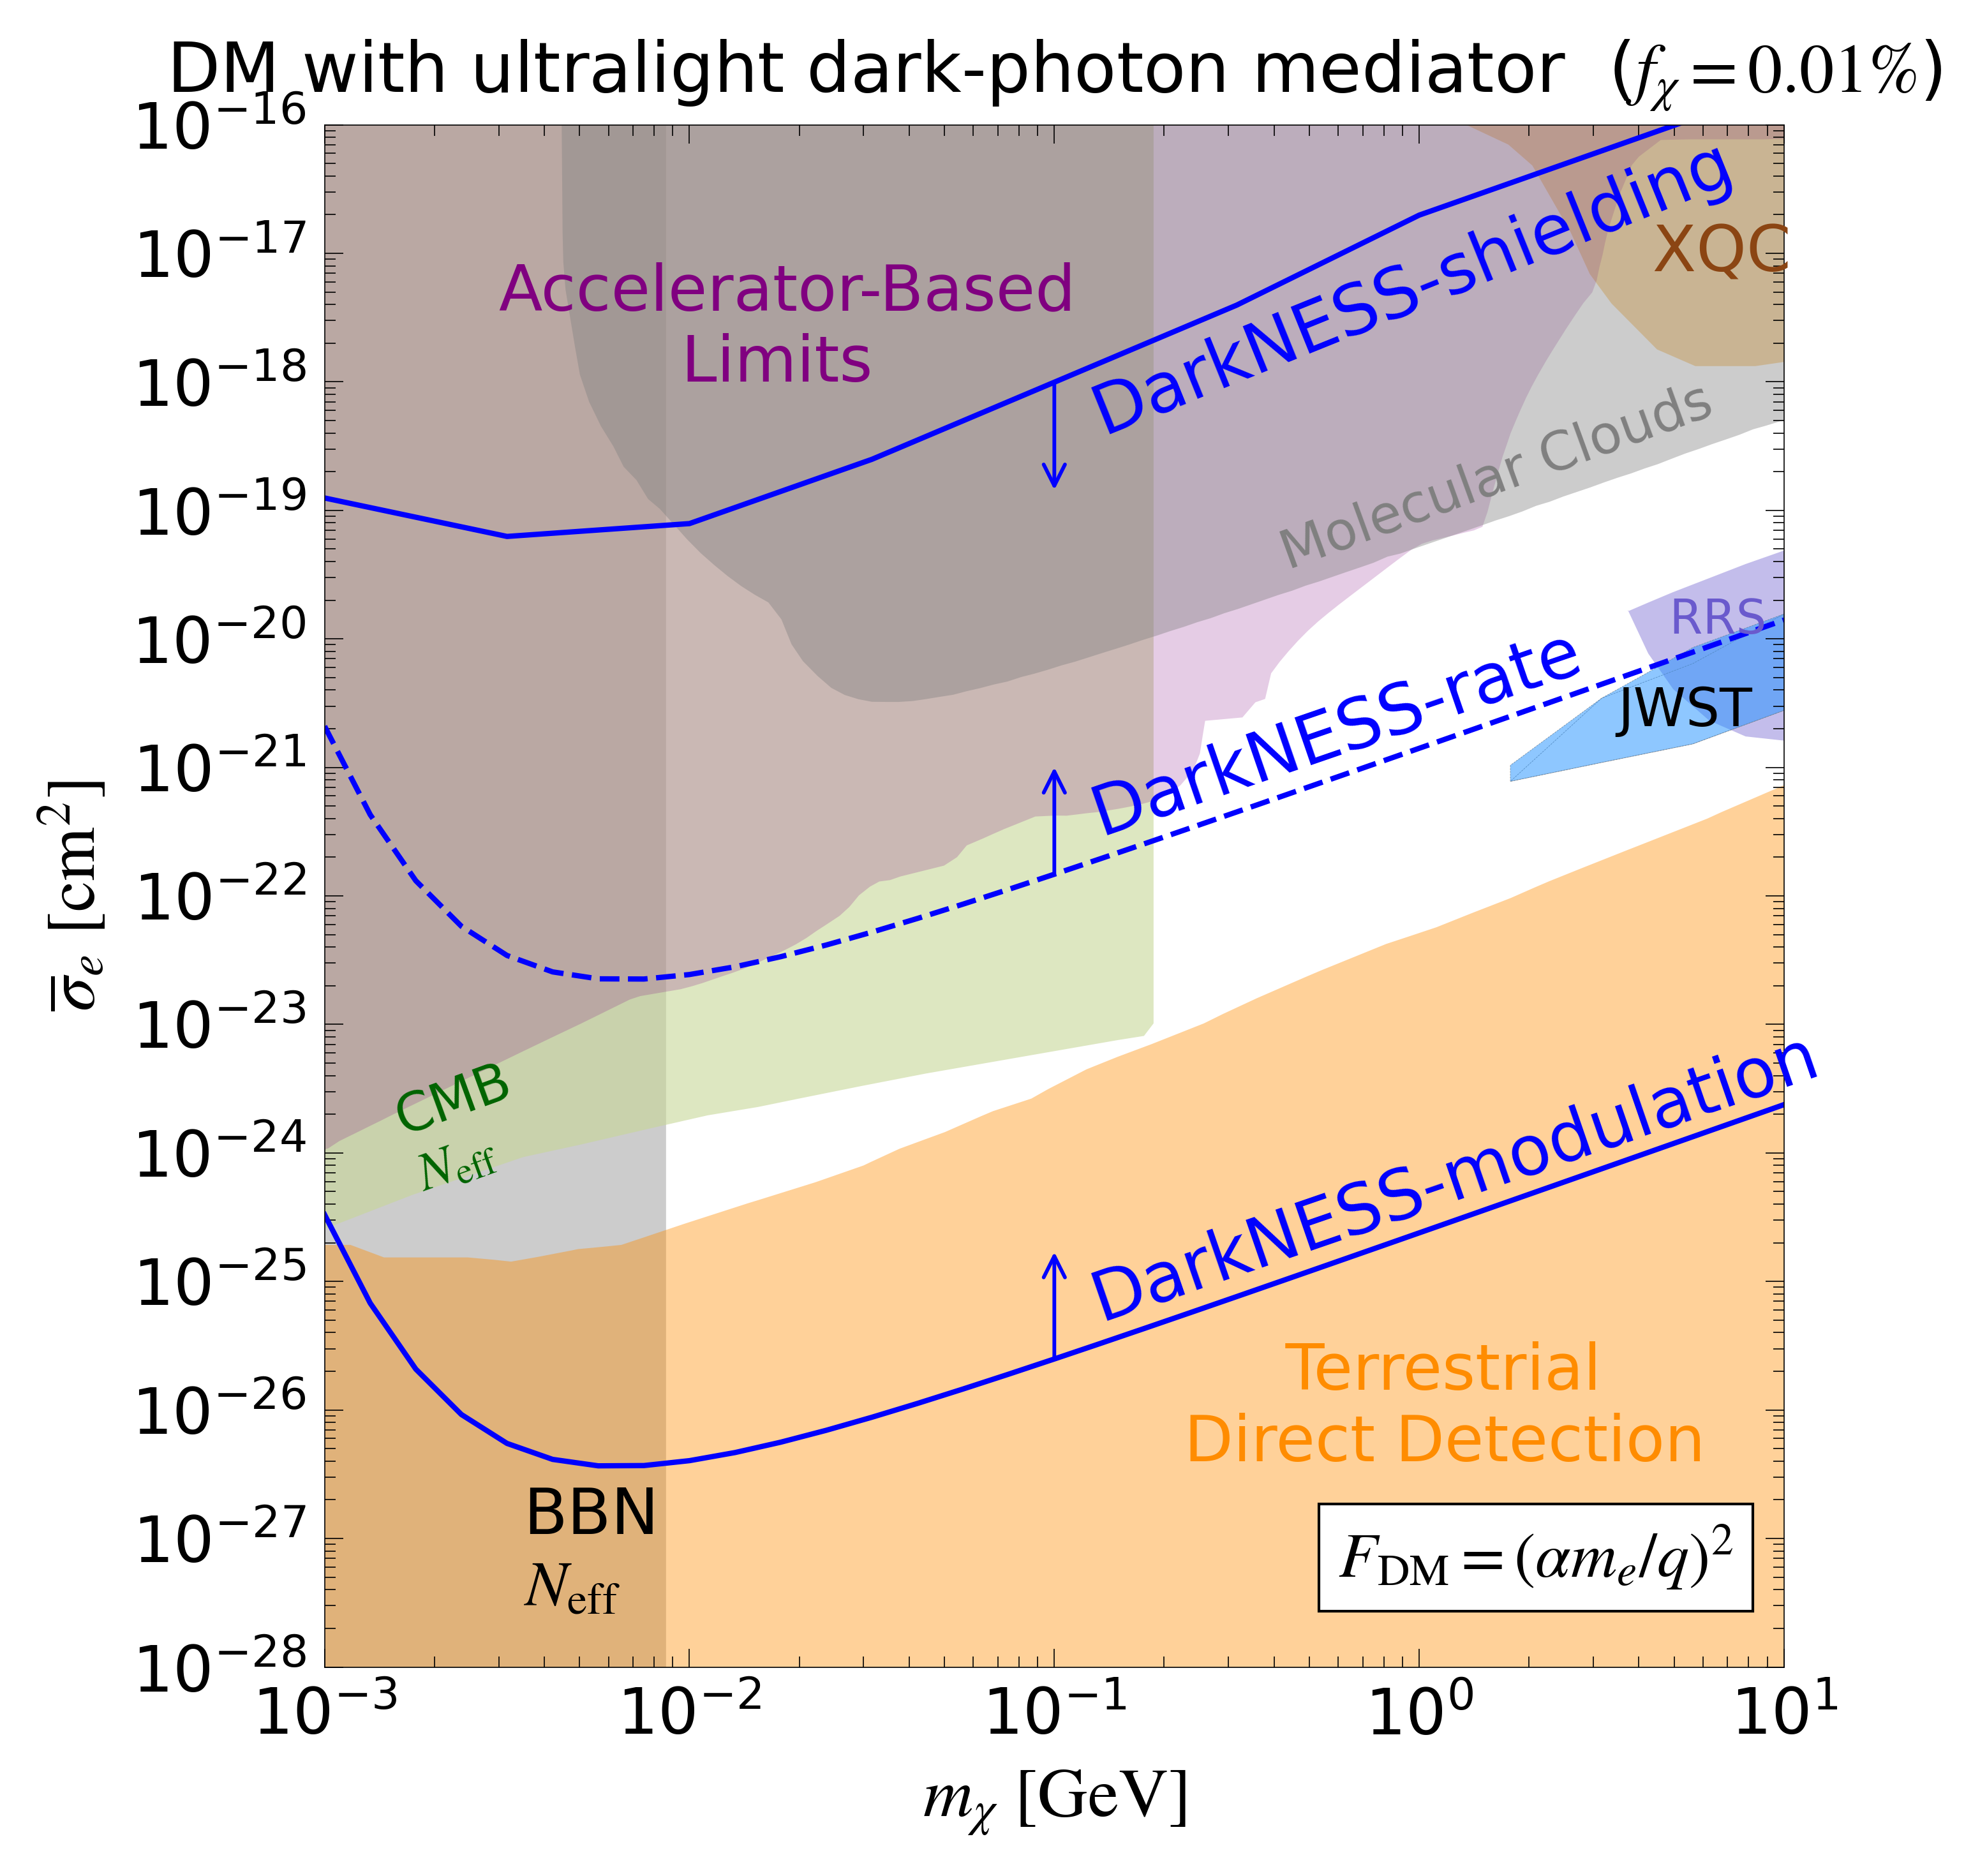

In [3]:
# 0.01%:
frac = '1e-4'
frac_rescale = float(frac) / 4e-3
output_dir = './advan_constraint/frac_' + frac + '/'
likelihood_output_dir = output_dir + 'log_likelihood_grid/'
constraint_grid_dir = output_dir + 'constraints/'
best_constraint_grid = np.zeros((n_cs,n_m))
for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_constraint_grid += constraint_grid
best_constraint_grid = (best_constraint_grid>0)
find_non_zero = np.sum(best_constraint_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_upper_limit = np.zeros((n_m - constraint_start, 2))
best_lower_limit = np.zeros((n_m - constraint_start, 2))
for col in range(constraint_start, n_m):
    indices = np.where(best_constraint_grid[:, col] == 1)[0]
    upper_index = n_cs -1 - np.min(indices)
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_upper_limit[index_temp, 0] = m_grid[col]
    best_lower_limit[index_temp, 0] = m_grid[col]
    best_upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
    best_lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]

#plot parameters
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16

fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
ax.fill_between(XQC[:,0], XQC[:,1] / frac_rescale, plt_ymax, color='#FBCF89', alpha=0.8, edgecolor=None)
RRS_x_points = np.array([3.73216038, 4.2441582 , 4.96626371, 6.24144805, 7.84406065, 9.85817506, 10])
ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points) / frac_rescale, color = 'slateblue', alpha=0.4, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color='purple', alpha=0.2, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)
ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1] / frac_rescale, plt_ymax, color= 'gray', alpha=0.4, edgecolor=None)

for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    if np.sum(constraint_grid) == 0:
        continue
    find_non_zero = np.sum(constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    # JWST Result, here:
    ax.fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1], facecolor='none', edgecolor='gray',alpha = 0.9, linestyle='--', linewidth=0.1) 
ax.fill_between(best_lower_limit[:,0], best_lower_limit[:,1], best_upper_limit[:,1], facecolor='dodgerblue', alpha = 0.5, edgecolor=None)

ax.loglog(darkness_upper[:,0],darkness_upper[:,2], color='blue', linewidth = 1)
ax.loglog(darkness_rate[:,0],darkness_rate[:,1], color='blue', linestyle = '--', linewidth = 1)
ax.loglog(darkness_mod[:,0],darkness_mod[:,1], color='blue', linewidth = 1)

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.01\%$)', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.2, 4e-27, '      Terrestrial\n Direct Detection', fontsize=12, color='darkorange',rotation=0)
ax.text(3e-3, 1e-18, 'Accelerator-Based\n         Limits', fontsize=12, color='purple',alpha=1,rotation=0)
ax.text(3.5e-3, 3e-28, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(2.3, 2e-18, '     XQC\n', fontsize=12, color='saddlebrown', rotation=0)
ax.text(3, 4.2e-21, '     RRS\n', fontsize=9, color='slateblue',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='darkgreen', alpha=1,rotation=20)
ax.text(4e-1, 3.5e-20, 'Molecular Clouds', fontsize=10, color= 'gray', alpha=1, rotation=20)
#ax.text(1.5e-1, 2.3e-21, 'molecular cloud (diffuse)', fontsize=10, color='black',rotation=19)
ax.text(3.5, 2.1e-21, 'JWST', fontsize=10, color='black',rotation=0)  
ax.text(0.12, 4e-19, 'DarkNESS-shielding', fontsize=13, color='blue',rotation=22) 
ax.text(0.12, 3e-22, 'DarkNESS-rate', fontsize=13, color='blue',rotation=19) 
ax.text(0.12, 5e-26, 'DarkNESS-modulation', fontsize=13, color='blue',rotation=19) 
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
ax.annotate('', xy=(0.1, darkness_upper[4,2]/10*1.2), xytext=(0.1, darkness_upper[4,2]*1.2),
            arrowprops=dict(color='blue', arrowstyle='->', linewidth=0.7))
ax.annotate('', xy=(0.1, darkness_mod[17,1]*10/1.6), xytext=(0.1, darkness_mod[17,1]/1.6),
            arrowprops=dict(color='blue', arrowstyle='->', linewidth=0.7))
ax.annotate('', xy=(0.1, darkness_rate[17,1]*10/1.6), xytext=(0.1, darkness_rate[17,1]/1.6),
            arrowprops=dict(color='blue', arrowstyle='->', linewidth=0.7))
plt.tight_layout()
plt.savefig('DarkNESS.pdf', format="pdf",bbox_inches="tight")
plt.show()

In [4]:
darkness_upper

array([[1.00000000e-03, 1.22353000e-21, 1.24840000e-19],
       [3.16228000e-03, 1.48553000e-23, 6.26770000e-20],
       [1.00000000e-02, 1.12162000e-23, 7.89056000e-20],
       [3.16228000e-02, 2.44022000e-23, 2.49522000e-19],
       [1.00000000e-01, 6.92161000e-23, 9.93363000e-19],
       [3.16228000e-01, 2.11693000e-22, 3.95465000e-18],
       [1.00000000e+00, 6.62466000e-22, 1.98202000e-17],
       [3.16228000e+00, 2.08801000e-21, 6.26770000e-17],
       [1.00000000e+01, 6.58114644e-21, 1.98202154e-16]])